In [1]:
import numpy as np
#if this fails, you need to put the case_studies.py file in the same folder
from case_studies import *

In [2]:
from scipy.optimize import minimize

#These are the example optimizers you should evaluate this week.
#These are optimizers implemented in scipy.
#they take as first 2 or 3 arguments the function f, its gradient df and sometimes its hessian Hf.
#the next parameters are all the same: x0 is the starting point, max_iterations the stopping criterion for iterations
#and epsilon the precision tolerance to be reached. 
#Note: epsilon is interpreted slightly differently across algorithms, and some algorithms might not reach the tolerance
#and stop early.
def scipy_bfgs(f,df,x0,max_iterations,epsilon):
    xs=[]
    grad_norms=[]
    def logging_f(x):
        xs.append(x)
        grad_norms.append(np.maximum(np.linalg.norm(df(x)),10**(-5)*epsilon))
        return f(x)
    minimize(logging_f, x0, method="BFGS", jac=df, tol=epsilon,options={'maxiter':max_iterations, 'gtol':epsilon})
    return np.array(xs), np.array(grad_norms)

def scipy_newton(f,df,Hf,x0,max_iterations,epsilon):
    xs=[]
    grad_norms=[]
    def logging_f(x):
        xs.append(x)
        grad_norms.append(np.maximum(np.linalg.norm(df(x)),10**(-5)*epsilon))
        return f(x)
    minimize(logging_f, x0, method="Newton-CG", jac=df, hess=Hf, tol=epsilon,options={'maxiter':max_iterations,'xtol':epsilon})
    return np.array(xs), np.array(grad_norms)

def scipy_trust_region(f,df,Hf,x0,max_iterations,epsilon):
    xs=[]
    grad_norms=[]
    def logging_f(x):
        xs.append(x)
        grad_norms.append(np.maximum(np.linalg.norm(df(x)),10**(-5)*epsilon))
        return f(x)
    minimize(logging_f, x0, method="trust-exact", jac=df, hess=Hf, tol=epsilon,options={'maxiter':max_iterations})
    return np.array(xs), np.array(grad_norms)

In [ ]:
#example usage of the algorithms
#the output is a list of points evaluated on the function as well as the gradient norms at that point
#this algorithms has the first three arguments functions for function value, gradient and Hessian.
#For the 5 functions, those are named f1-f5 etc and cna be found in the case_studies.py file
x0=np.ones(2)
xs,grad_norms = scipy_trust_region(f4,df4,Hf4,x0, 1000, 1.e-10)

#the optimal point for a given function and dimensionality is stored in the package as well for at least 15 decimals precision
optimal = x_opt("f4", 2)
print("final solution point:", xs[-1])
print("distance of x from optimum", np.linalg.norm(xs[-1]-optimal))
print("number of function evaluations:", len(grad_norms))
print("final function value:", f4(xs[-1]))
print("final gradient norm:", grad_norms[-1])



final solution point: [0.00190933 0.00190933]
distance of x from optimum 1.1857524696459338e-11
number of function evaluations: 9
final function value: 1.2203194789920598e-05
final gradient norm: 9.977761920841575e-11


f1
<function f1 at 0x00000175E5112F20>
<function df1 at 0x00000175E5113240>
<function Hf1 at 0x00000175E51132E0>
Optimal solution for f1:  [0. 0.]


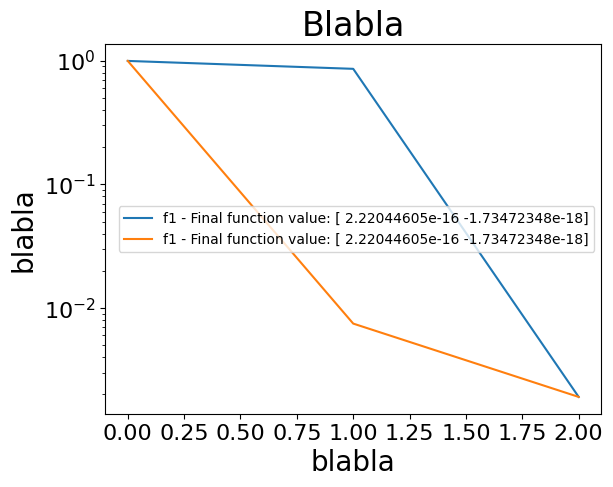

In [29]:
import matplotlib.pyplot as plt
F1 = np.array(["f1", f1, df1, Hf1])
F2 = np.array(["f2", f2, df2, Hf2])
F3 = np.array(["f3", f3, df3, Hf3])
F4 = np.array(["f4", f4, df4, Hf4])
F5 = np.array(["f5", f5, df5, Hf5])
F = np.array([F1])#, F2, F3, F4, F5])

x0=np.ones(2)
#plt.figure(figsize=(32, 32))
plt.yscale("log") #value : {"linear", "log", "symlog", "logit", ...}

for f in F:
    print(f[0])
    print(f[1])
    print(f[2])
    print(f[3])
    xs,grad_norms = scipy_trust_region(f[1],f[2],f[3],x0, 1000, 1.e-10)
    print("Optimal solution for " + f[0] + ": ", x_opt(f[0], 2))
    plt.plot(range(0,len(xs)), abs(xs-np.full_like(xs, optimal)), label = f"{f[0]} - Final function value: {xs[-1]}")

plt.legend()    
plt.title("Blabla", fontsize=24)
plt.xlabel("blabla", fontsize=20)
plt.ylabel("blabla", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()